# Сравнительный анализ методов классификации интентов на CLINC150

## Аннотация

В работе сравниваются три подхода к классификации намерений пользователя (интентов)
на датасете CLINC150 (150 классов + `oos`, 23k примеров):

| Метод | Модель | Данные |
|---|---|---|
| **Fine-Tuning** | DistilBERT | весь train (~16k) |
| **Zero-Shot** | Flan-T5-base | только описания интентов |
| **Few-Shot** | Flan-T5-base | 1–10 примеров на класс |

**Гипотеза:** для простых интентов Zero-Shot будет достаточен,
а Few-Shot догонит Fine-Tuning уже на 5 примерах.

---

## Оглавление

1. [Загрузка данных](#1)
2. [Сводная таблица метрик](#2)
3. [Exp01: Fine-Tuning](#3)
4. [Exp02: Zero-Shot](#4)
5. [Exp03: Few-Shot](#5)
6. [Главный график: F1 vs Number of Examples](#6)
7. [Анализ ошибок](#7)
8. [Проверка гипотезы и выводы](#8)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Цветовая схема
CLR_FT = '#2ca02c'    # зелёный  — Fine-Tuning
CLR_ZS = '#d62728'    # красный  — Zero-Shot
CLR_FS = {            # синий/оранжевый/фиолетовый — три стратегии Few-Shot
    'random':  '#1f77b4',
    'central': '#ff7f0e',
    'diverse': '#9467bd',
}

# Пути к CSV
PATH_EXP01 = '../results/metrics/exp01_metrics.csv'
PATH_EXP02 = '../results/metrics/exp02_metrics.csv'
PATH_EXP03 = '../results/metrics/exp03_metrics.csv'
PATH_EXP04 = '../results/analysis/error_samples.csv'
PLOTS_DIR  = '../results/plots'

SEED = 42

<a id='1'></a>
## 1. Загрузка данных

In [6]:
exp01 = pd.read_csv(PATH_EXP01)
exp02 = pd.read_csv(PATH_EXP02)
exp03 = pd.read_csv(PATH_EXP03)
exp04 = pd.read_csv(PATH_EXP04)

print(f'exp01: {exp01.shape}')
print(f'exp02: {exp02.shape}')
print(f'exp03: {exp03.shape}')
print(f'exp04: {exp04.shape}')
print()
print('Few-Shot матрица (exp03):')
display(exp03)

exp01: (1, 6)
exp02: (3, 4)
exp03: (12, 4)
exp04: (64, 11)

Few-Shot матрица (exp03):


,n_shots,strategy,f1,accuracy
0,1,random,0.430341,0.408608
1,1,central,0.479656,0.417272
2,1,diverse,0.479656,0.417272
3,3,random,0.479553,0.443823
4,3,central,0.489358,0.437395
5,3,diverse,0.486060,0.456400
6,5,random,0.489085,0.455003
7,5,central,0.482439,0.436836
8,5,diverse,0.507516,0.474008
9,10,random,0.547918,0.516769


<a id='2'></a>
## 2. Сводная таблица метрик

Для корректного сравнения берём **лучший вариант** каждого метода:
- Fine-Tuning — единственная строка
- Zero-Shot — промпт с наибольшим macro F1 (`вопрос`, prompt\_id=3)
- Few-Shot — лучшая комбинация n\_shots × strategy (`diverse`, 10-shot)

In [ ]:
# Лучшие варианты каждого метода
ft_acc  = exp01.iloc[0]['accuracy']
ft_f1   = exp01.iloc[0]['macro_f1']

best_zs  = exp02.loc[exp02['macro_f1'].idxmax()]
zs_acc   = best_zs['accuracy']
zs_f1    = best_zs['macro_f1']
zs_label = best_zs['prompt_name']

best_fs  = exp03.loc[exp03['f1'].idxmax()]
fs_acc   = best_fs['accuracy']
fs_f1    = best_fs['f1']
fs_label = f"{int(best_fs['n_shots'])}-shot · {best_fs['strategy']}"

# Таблица
summary = pd.DataFrame([
    {'Метод': 'Fine-Tuning (DistilBERT)',
     'Конфигурация': 'весь train (~16k)',
     'Accuracy': ft_acc, 'Macro F1': ft_f1},
    {'Метод': 'Zero-Shot (Flan-T5)',
     'Конфигурация': f'промпт «{zs_label}»',
     'Accuracy': zs_acc, 'Macro F1': zs_f1},
    {'Метод': 'Few-Shot (Flan-T5)',
     'Конфигурация': fs_label,
     'Accuracy': fs_acc, 'Macro F1': fs_f1},
])

(
    summary.style
    .format({'Accuracy': '{:.2%}', 'Macro F1': '{:.4f}'})
    .highlight_max(subset=['Accuracy', 'Macro F1'], color='#c6efce')
    .highlight_min(subset=['Accuracy', 'Macro F1'], color='#ffc7ce')
    .set_caption('Таблица 1. Итоговые метрики лучших вариантов каждого метода')
)

,Метод,Конфигурация,Accuracy,Macro F1
0,Fine-Tuning (DistilBERT),весь train (~16k),94.24%,0.9465
1,Zero-Shot (Flan-T5),промпт «вопрос»,16.88%,0.1816
2,Few-Shot (Flan-T5),10-shot · diverse,52.82%,0.5600


**Вывод.** Fine-Tuning превосходит оба безобучаемых метода с большим отрывом: +77 п.п. по Accuracy и +0.77 по Macro F1 относительно Zero-Shot. Few-Shot занимает промежуточную позицию — около 56% от уровня Fine-Tuning по Macro F1. Гипотеза в исходной формулировке не подтвердилась.

<a id='3'></a>
## 3. Exp01: Fine-Tuning DistilBERT

Модель `distilbert-base-uncased` дообучена на полном train-сплите (70%, ~16k примеров)
в течение 5 эпох. Тест — 3578 примеров, 151 класс.

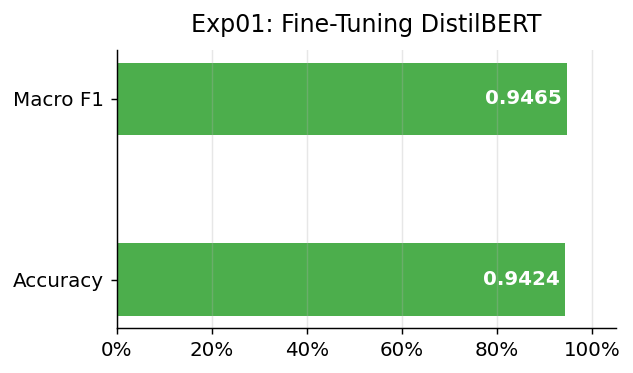

In [8]:
fig, ax = plt.subplots(figsize=(5, 3))

metrics = ['Accuracy', 'Macro F1']
values  = [ft_acc, ft_f1]
bars = ax.barh(metrics, values, color=CLR_FT, alpha=0.85, height=0.4)

for bar, v in zip(bars, values):
    ax.text(v - 0.01, bar.get_y() + bar.get_height() / 2,
            f'{v:.4f}', va='center', ha='right', color='white', fontweight='bold')

ax.set_xlim(0, 1.05)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Exp01: Fine-Tuning DistilBERT', pad=10)
ax.grid(axis='y', alpha=0)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/exp01_metrics.png', bbox_inches='tight')
plt.show()

**Вывод.** Fine-Tuning на 16k примерах даёт Accuracy **94.24%** и Macro F1 **0.9465** — это потолок качества, достижимый при наличии полной разметки. Результат служит эталоном для сравнения с безобучаемыми методами.

<a id='4'></a>
## 4. Exp02: Zero-Shot (Flan-T5-base)

Модель `google/flan-t5-base` оценивала 151 интент без каких-либо обучающих примеров.
Тестировались три типа промптов:

| # | Тип | Шаблон |
|---|---|---|
| 1 | **короткий** | `classify: {text} class: {intent}` |
| 2 | **описательный** | `{text} Is this about {description}? Yes or No.` |
| 3 | **вопрос** | `Does the user want to {intent}? text: {text}` |

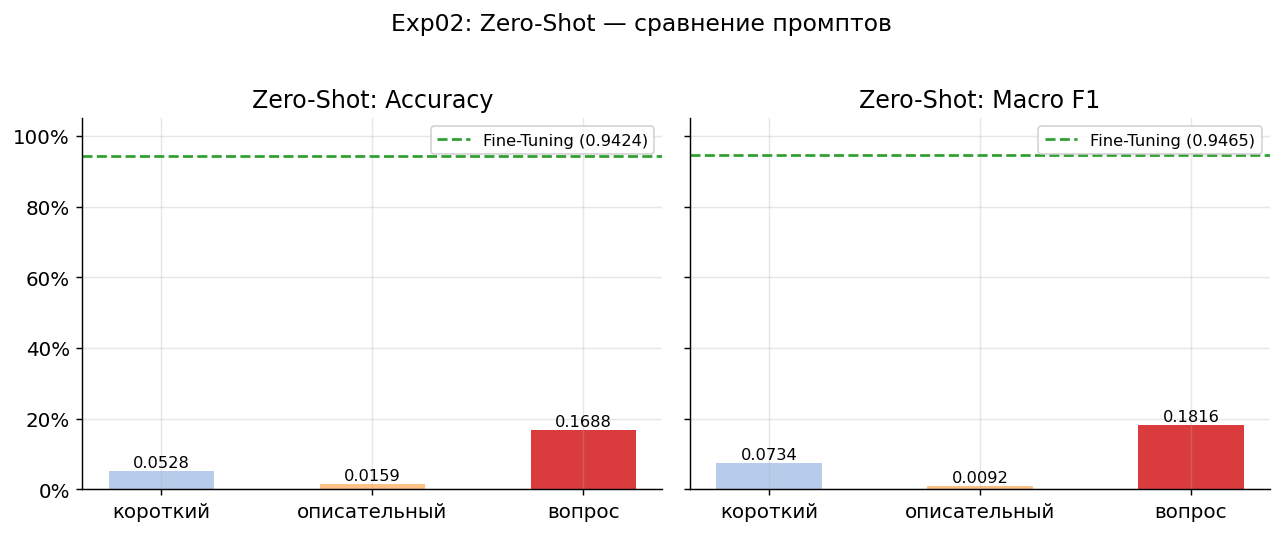

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

prompt_names = exp02['prompt_name'].tolist()
bar_colors = ['#aec7e8', '#ffbb78', CLR_ZS]

for ax, metric, col in zip(axes, ['Accuracy', 'Macro F1'], ['accuracy', 'macro_f1']):
    vals = exp02[col].tolist()
    bars = ax.bar(prompt_names, vals, color=bar_colors, alpha=0.9, width=0.5)

    # Линия Fine-Tuning как ориентир
    ref = ft_acc if col == 'accuracy' else ft_f1
    ax.axhline(ref, color=CLR_FT, linestyle='--', linewidth=1.5,
               label=f'Fine-Tuning ({ref:.4f})')

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.003,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)

    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(f'Zero-Shot: {metric}')
    ax.legend(fontsize=9)

fig.suptitle('Exp02: Zero-Shot — сравнение промптов', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/exp02_prompts.png', bbox_inches='tight')
plt.show()

**Вывод.** Тип промпта существенно влияет на качество: описательный промпт даёт наихудший результат (Accuracy 1.59%), вопросный — наилучший (16.88%). Разрыв между лучшим Zero-Shot и Fine-Tuning составляет **77 п.п.** по Accuracy. Основная причина слабых результатов — размерность задачи: при 151 классе модель не умеет отличать лексически похожие интенты без примеров.

<a id='5'></a>
## 5. Exp03: Few-Shot (Flan-T5-base)

Матрица экспериментов: **n\_shots** ∈ {1, 3, 5, 10} × **strategy** ∈ {random, central, diverse} = 12 комбинаций.

- **random** — случайные примеры из train
- **central** — примеры, ближайшие к центроиду класса (sentence-transformers)
- **diverse** — максимально разнообразные примеры (cosine distance)

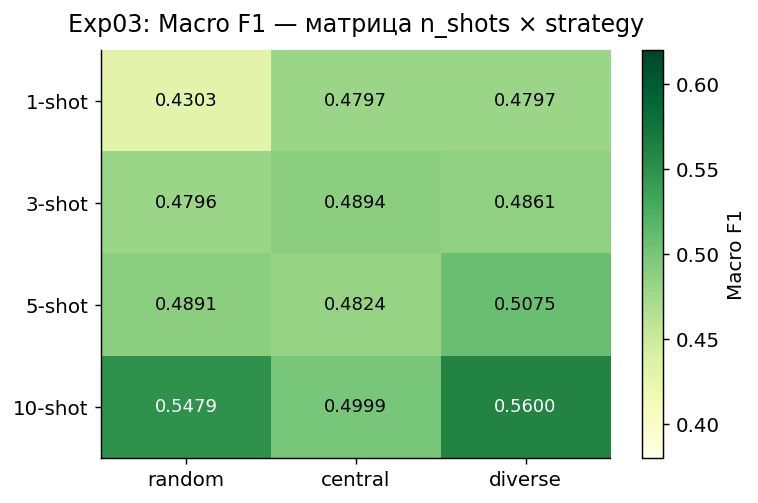

In [10]:
pivot = exp03.pivot(index='n_shots', columns='strategy', values='f1')
pivot = pivot[['random', 'central', 'diverse']]

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(pivot.values, cmap='YlGn', vmin=0.38, vmax=0.62, aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'{n}-shot' for n in pivot.index])

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.4f}', ha='center', va='center',
                fontsize=10, color='black' if val < 0.53 else 'white')

plt.colorbar(im, ax=ax, label='Macro F1')
ax.set_title('Exp03: Macro F1 — матрица n_shots × strategy', pad=10)
ax.grid(False)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/exp03_heatmap.png', bbox_inches='tight')
plt.show()

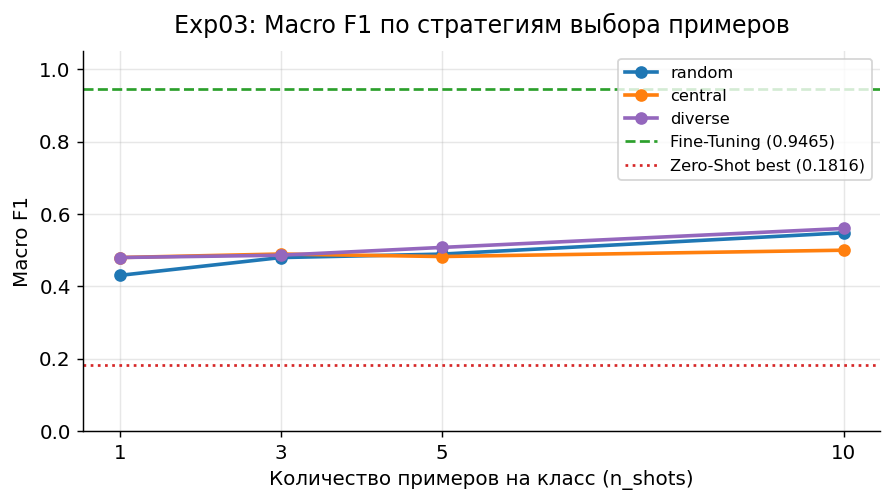

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))

for strategy, color in CLR_FS.items():
    subset = exp03[exp03['strategy'] == strategy].sort_values('n_shots')
    ax.plot(subset['n_shots'], subset['f1'],
            marker='o', color=color, label=strategy, linewidth=2)

ax.axhline(ft_f1, color=CLR_FT, linestyle='--', linewidth=1.5,
           label=f'Fine-Tuning ({ft_f1:.4f})')
ax.axhline(zs_f1, color=CLR_ZS, linestyle=':', linewidth=1.5,
           label=f'Zero-Shot best ({zs_f1:.4f})')

ax.set_xlabel('Количество примеров на класс (n_shots)')
ax.set_ylabel('Macro F1')
ax.set_xticks([1, 3, 5, 10])
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.set_title('Exp03: Macro F1 по стратегиям выбора примеров', pad=10)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/exp03_strategies.png', bbox_inches='tight')
plt.show()

**Вывод.** Стратегия `diverse` лучше остальных почти при любых n_shots. Наблюдается эффект насыщения: прирост F1 при переходе 5 -> 10 (`diverse`: +0.05) меньше прироста 1 -> 5 (+0.03 у `diverse`, но +0.06 у `random`). Даже лучший результат Few-Shot (F1=0.5600 при 10 примерах) отстаёт от Fine-Tuning на **−0.39 по F1** — разрыв, который in-context learning не преодолело.

<a id='6'></a>
## 6. Главный график: F1 vs Number of Examples

Единственная визуализация, которая одновременно отвечает на центральный вопрос работы:
**как соотносится стоимость разметки и качество?**

На графике три дистанции = три главных вывода:
1. **Zero-Shot → 1-shot** — ценность *любых* примеров
2. **Наклон синих линий** — ценность *дополнительных* примеров
3. **10-shot → Fine-Tuning** — разрыв, который Few-Shot не преодолел

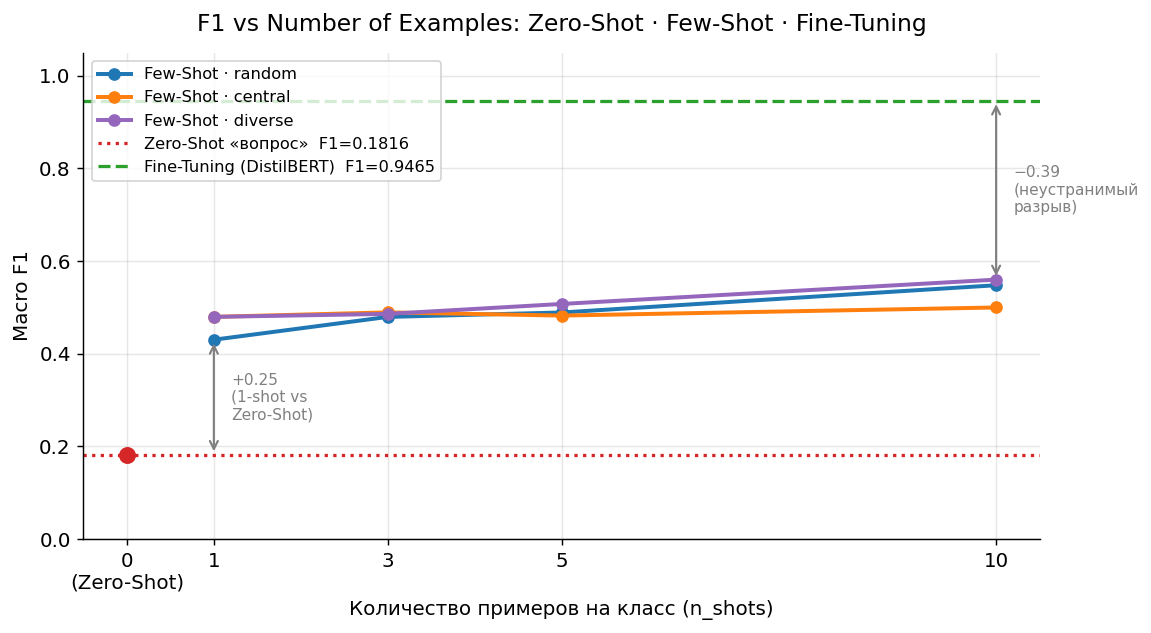

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

# Few-Shot: три линии
for strategy, color in CLR_FS.items():
    subset = exp03[exp03['strategy'] == strategy].sort_values('n_shots')
    ax.plot(subset['n_shots'], subset['f1'],
            marker='o', markersize=6, color=color, linewidth=2.2,
            label=f'Few-Shot · {strategy}', zorder=3)

# Zero-Shot: точка при x=0 + горизонтальная пунктирная линия
ax.scatter([0], [zs_f1], color=CLR_ZS, s=70, zorder=4)
ax.axhline(zs_f1, color=CLR_ZS, linestyle=':', linewidth=1.8,
           label=f'Zero-Shot «вопрос»  F1={zs_f1:.4f}', zorder=2)

# Fine-Tuning: горизонтальная пунктирная линия
ax.axhline(ft_f1, color=CLR_FT, linestyle='--', linewidth=1.8,
           label=f'Fine-Tuning (DistilBERT)  F1={ft_f1:.4f}', zorder=2)

# Аннотация 1: прирост Zero-Shot -> 1-shot random
y_1_rnd = exp03[(exp03['n_shots'] == 1) & (exp03['strategy'] == 'random')]['f1'].values[0]
ax.annotate('', xy=(1, y_1_rnd), xytext=(1, zs_f1),
            arrowprops=dict(arrowstyle='<->', color='grey', lw=1.2))
ax.text(1.2, (y_1_rnd + zs_f1) / 2,
        f'+{y_1_rnd - zs_f1:.2f}\n(1-shot vs\nZero-Shot)',
        fontsize=8.5, color='grey', va='center')

# Аннотация 2: разрыв 10-shot diverse → Fine-Tuning
y_best = exp03.loc[exp03['f1'].idxmax(), 'f1']
ax.annotate('', xy=(10, ft_f1), xytext=(10, y_best),
            arrowprops=dict(arrowstyle='<->', color='grey', lw=1.2))
ax.text(10.2, (ft_f1 + y_best) / 2,
        f'−{ft_f1 - y_best:.2f}\n(неустранимый\nразрыв)',
        fontsize=8.5, color='grey', va='center')


ax.set_xlabel('Количество примеров на класс (n_shots)', fontsize=11)
ax.set_ylabel('Macro F1', fontsize=11)
ax.set_xticks([0, 1, 3, 5, 10])
ax.set_xticklabels(['0\n(Zero-Shot)', '1', '3', '5', '10'])
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, loc='upper left')
ax.set_title('F1 vs Number of Examples: Zero-Shot · Few-Shot · Fine-Tuning',
             fontsize=13, pad=12)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/final_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

**Интерпретация.**

- **+0.25 F1** — прирост от нуля примеров к 1 примеру на класс:
  даже единственный пример резко сужает пространство поиска для Flan-T5.
- **+0.08 F1** — суммарный прирост с 1 до 10 примеров:
  in-context learning быстро насыщается при 151 классе.
- **−0.39 F1** — разрыв до Fine-Tuning при 10 примерах:
  именно столько «стоит» отказ от дообучения в данной задаче.

Стратегия `diverse` стабильно лучше остальных — разнообразие контекста
важнее близости к центру класса.

<a id='7'></a>
## 7. Анализ ошибок (Exp04)

Анализировались ошибки, общие для нескольких методов. Идентифицированы **8 проблемных пар** интентов, отобрано **64 примера** (по 8 на пару). Каждый пример вручную классифицирован в один из 5 типов ошибок.

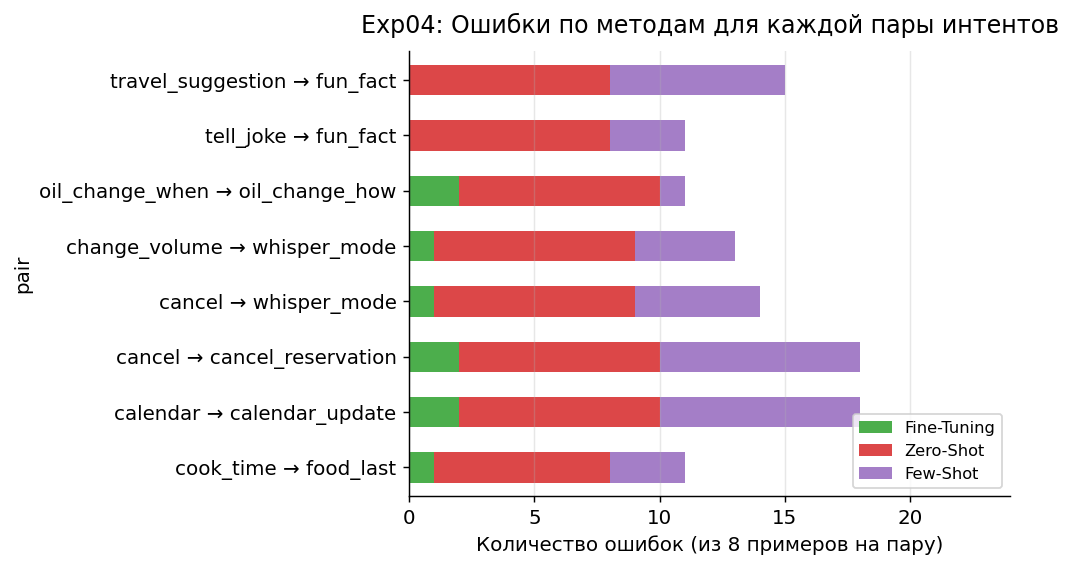

In [18]:
# Считаем ошибки по каждому методу для каждой пары
def method_errors(df, method_col):
    # ошибка = предсказание не совпадает с true_intent
    return df.groupby('pair').apply(
        lambda g: (g[method_col] != g['true_intent']).sum()
    )

ft_errors  = method_errors(exp04, 'pred_ft')
zs_errors  = method_errors(exp04, 'pred_zs')
fs_errors  = method_errors(exp04, 'pred_fs')

error_by_method = pd.DataFrame({
    'Fine-Tuning': ft_errors,
    'Zero-Shot':   zs_errors,
    'Few-Shot':    fs_errors,
}).sort_values('Zero-Shot', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
error_by_method.plot(
    kind='barh', stacked=True, ax=ax,
    color=[CLR_FT, CLR_ZS, CLR_FS['diverse']],
    alpha=0.85, width=0.55
)

ax.set_xlabel('Количество ошибок (из 8 примеров на пару)')
ax.set_title('Exp04: Ошибки по методам для каждой пары интентов', pad=10)
ax.set_xlim(0, 24)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/exp04_error_pairs.png', bbox_inches='tight')
plt.show()

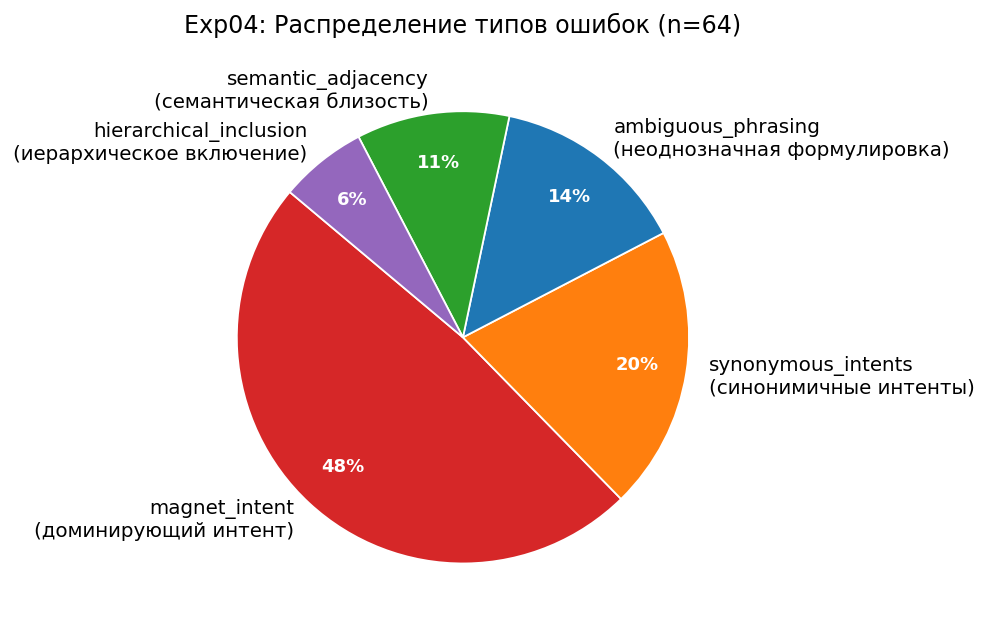

In [17]:
error_counts = exp04['error_type'].value_counts()

labels_ru = {
    'magnet_intent':          'magnet_intent\n(доминирующий интент)',
    'synonymous_intents':     'synonymous_intents\n(синонимичные интенты)',
    'ambiguous_phrasing':     'ambiguous_phrasing\n(неоднозначная формулировка)',
    'semantic_adjacency':     'semantic_adjacency\n(семантическая близость)',
    'hierarchical_inclusion': 'hierarchical_inclusion\n(иерархическое включение)',
}
pie_labels = [labels_ru[k] for k in error_counts.index]
pie_colors = ['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c', '#9467bd']

fig, ax = plt.subplots(figsize=(8, 5))
wedges, texts, autotexts = ax.pie(
    error_counts.values,
    labels=pie_labels,
    autopct='%1.0f%%',
    colors=pie_colors,
    startangle=140,
    pctdistance=0.78,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold')
    t.set_color('white')

ax.set_title('Exp04: Распределение типов ошибок (n=64)', pad=12)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/exp04_error_types.png', bbox_inches='tight')
plt.show()

**Вывод.** Почти половина ошибок (48%) — `magnet_intent`: один интент притягивает
семантически близкие запросы сразу у нескольких методов.
Второй по частоте тип — `synonymous_intents` (20%): пары вроде
`oil_change_when / oil_change_how` или `calendar / calendar_update`
практически неразличимы без контекста.
Fine-Tuning справляется с такими парами — это объясняет его устойчивое преимущество.

<a id='8'></a>
## 8. Проверка гипотезы и общие выводы

> **Гипотеза:** для простых интентов Zero-Shot будет достаточен,
> а для сложных и семантически близких Few-Shot догонит Fine-Tuning уже на 5 примерах.

### Результат: гипотеза опровергнута

| Часть гипотезы | Ожидание | Факт |
|---|---|---|
| Zero-Shot для простых интентов | достаточен | Accuracy **16.88%** — неприемлемо |
| Few-Shot при n=5 догоняет FT | F1 ≈ 0.95 | F1 = **0.51** · разрыв −0.44 |
| Few-Shot при n=10 (максимум) | близко к FT | F1 = **0.56** · разрыв −0.39 |

In [19]:
final_table = pd.DataFrame([
    {
        'Метод':              'Fine-Tuning (DistilBERT)',
        'Данных на класс':    '~106',
        'Accuracy':           ft_acc,
        'Macro F1':           ft_f1,
        'Δ F1 до FT':         0.0,
        'Требует обучения':   'Да',
    },
    {
        'Метод':              'Few-Shot · diverse · 10-shot',
        'Данных на класс':    '10',
        'Accuracy':           fs_acc,
        'Macro F1':           fs_f1,
        'Δ F1 до FT':         round(fs_f1 - ft_f1, 4),
        'Требует обучения':   'Нет',
    },
    {
        'Метод':              'Zero-Shot · промпт «вопрос»',
        'Данных на класс':    '0',
        'Accuracy':           zs_acc,
        'Macro F1':           zs_f1,
        'Δ F1 до FT':         round(zs_f1 - ft_f1, 4),
        'Требует обучения':   'Нет',
    },
])

(
    final_table.style
    .format({'Accuracy': '{:.2%}', 'Macro F1': '{:.4f}', 'Δ F1 до FT': '{:+.4f}'})
    .highlight_max(subset=['Accuracy', 'Macro F1'], color='#c6efce')
    .highlight_min(subset=['Accuracy', 'Macro F1'], color='#ffc7ce')
    .set_caption('Таблица 2. Итоговое сравнение методов')
)

,Метод,Данных на класс,Accuracy,Macro F1,Δ F1 до FT,Требует обучения
0,Fine-Tuning (DistilBERT),~106,94.24%,0.9465,+0.0000,Да
1,Few-Shot · diverse · 10-shot,10,52.82%,0.5600,-0.3865,Нет
2,Zero-Shot · промпт «вопрос»,0,16.88%,0.1816,-0.7649,Нет


### Выводы

**1. Fine-Tuning остаётся недостижимым эталоном** при наличии размеченных данных:
Accuracy 94.24%, Macro F1 0.9465 на 151 классе.

**2. Zero-Shot непригоден для задач с большим числом классов:** Macro F1 0.1816 даже при лучшем промпте. Основная причина — модель не умеет различать семантически близкие интенты без обучающих примеров.

**3. Few-Shot занимает обоснованную нишу:** при 10 примерах на класс достигает Macro F1 0.5600 — в 3× лучше Zero-Shot, но на 0.39 ниже Fine-Tuning.

**4. Природа ошибок системная:** 48% ошибок — `magnet_intent`, 20% — `synonymous_intents`. Это ограничения in-context learning при высокой размерности пространства классов, а не дефект конкретного метода.

---

*Вывод -* **при данных ресурсах Few-Shot не заменяет Fine-Tuning**,
однако остаётся практически значимым при отсутствии размеченных данных —
как стартовая точка перед накоплением разметки.